<a href="https://colab.research.google.com/github/jwliu24/Uber-Operational-Analysis/blob/main/Week_6_Product_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color:#0f172a; color:#5eead4; padding:28px; border-radius:12px;">
  <h1 style="font-size:28px; font-family:Calibri; margin-bottom:8px;">Product Analytics</h1>
  <p style="font-size:17px; font-family:Calibri; color:#e2e8f0; line-height:1.7em;">
    Raw data tells you what happened. Product analytics tells you <strong>whether your product is healthy</strong> - and where to focus next.
    <br><br>
    This session you will learn to build four metrics that every product team tracks:
  </p>
  <ul style="font-size:16px; font-family:Calibri; color:#e2e8f0; line-height:2em;">
    <li>📈 <strong>Ride Volume Growth</strong> - is demand trending up or down?</li>
    <li>💰 <strong>Average Revenue Per Ride (ARPR)</strong> - how much is each ride worth?</li>
    <li>🔁 <strong>Retention Proxy</strong> - are users coming back?</li>
    <li>🔽 <strong>Conversion Funnel</strong> - where are we losing rides?</li>
  </ul>
  <p style="font-size:15px; font-family:Calibri; color:#94a3b8; margin-top:14px;">
    <strong>Dataset:</strong> 150,000 ride bookings &nbsp;|&nbsp;
    <strong>Tools:</strong> pandas, matplotlib, seaborn &nbsp;|&nbsp;
    <strong>Time:</strong> ~45 minutes
  </p>
</div>

---
## Background: What Are Proxy KPIs?

A **KPI (Key Performance Indicator)** is a number that tells you how well a product or business is performing against a goal.

A **Proxy KPI** is a stand-in measurement used when the ideal metric is hard or impossible to measure directly.

| What we really want to know | Proxy we can actually measure |
|---|---|
| Are users loyal to our platform? | How many return within 30 days? |
| Is demand growing? | Are weekly booking volumes increasing? |
| Are drivers performing well? | What is the average driver rating per week? |
| Is our onboarding working? | What % of new users complete a 2nd ride? |

**Why proxies?** Because true loyalty, demand health, or satisfaction are feelings - proxies are the data shadows those feelings cast.

> 💡 The skill in product analytics is picking a proxy that is *closely enough correlated* with what you actually care about that optimising for it moves the real metric.

---
## Step 1: Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.patches import FancyArrowPatch

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

---
## Step 2: Load & Prepare the Data

In [18]:
# Upload uber_rides_data_processed.csv when prompted
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/uber_rides_data_processed.csv'

df = pd.read_csv(file_path)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\nBooking Status breakdown:')
print(df['Booking Status'].value_counts())
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: 150,000 rows × 30 columns

Booking Status breakdown:
Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,is_successful,is_cancelled_customer,is_cancelled_driver,is_incomplete,DateTime,Hour,DayOfWeek,Month,IsWeekend
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,2024-03-23 12:29:38,12,Saturday,3,True
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.90,14.00,NaN,NaN,NaN,NaN,1.00,Vehicle Breakdown,237.00,5.73,NaN,NaN,UPI,False,False,False,True,2024-11-29 18:01:39,18,Friday,11,False
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.40,25.80,NaN,NaN,NaN,NaN,NaN,NaN,627.00,13.58,4.90,4.90,Debit Card,True,False,False,False,2024-08-23 08:56:10,8,Friday,8,False


In [19]:
# ── Parse timestamps ────────────────────────────────────────────────────────
df['Date']     = pd.to_datetime(df['Date'], errors='coerce')
df['datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce'
)

# Granular time fields — we'll use all of these throughout
df['hour']       = df['datetime'].dt.hour
df['weekday']    = df['datetime'].dt.dayofweek   # 0=Mon, 6=Sun
df['month']      = df['datetime'].dt.month
df['year_month'] = df['datetime'].dt.to_period('M')   # e.g. '2024-03'
df['year_week']  = df['datetime'].dt.strftime('%Y-W%V')  # e.g. '2024-W12'

# Convenience flag
df['is_completed'] = (df['Booking Status'] == 'Completed').astype(int)

print('Date range:', df['Date'].min().date(), '→', df['Date'].max().date())
print('Months covered:', df['year_month'].nunique())
print('Weeks covered:', df['year_week'].nunique())

Date range: 2024-01-01 → 2024-12-30
Months covered: 12
Weeks covered: 52


---
## Metric 1: Ride Volume Growth

**Business question:** Is demand for our platform growing, flat, or declining?

**Why it matters:** Volume growth is the most fundamental health indicator. A declining volume trend signals churn, market saturation, or competitive pressure - even before revenue drops.

**How we measure it:**
- Count rides booked per month
- Calculate Month-over-Month (MoM) % change: `(this month − last month) / last month × 100`
- Visualise the trend over the full year

In [20]:
# ── Step 1: Count rides per month ───────────────────────────────────────────
monthly = (
    df.groupby('year_month')
    .size()
    .reset_index(name='rides')
)
monthly['month_label'] = monthly['year_month'].astype(str)

# ── Step 2: Calculate Month-over-Month growth ───────────────────────────────
# pct_change() computes (current - previous) / previous for each row
monthly['mom_pct'] = monthly['rides'].pct_change() * 100

print('Monthly ride volumes:')
print(monthly[['month_label', 'rides', 'mom_pct']].to_string(index=False))

peak_month = monthly.loc[monthly['rides'].idxmax(), 'month_label']
low_month  = monthly.loc[monthly['rides'].idxmin(), 'month_label']
print(f'\n📌 Peak month:   {peak_month} ({monthly["rides"].max():,} rides)')
print(f'📌 Lowest month: {low_month} ({monthly["rides"].min():,} rides)')

Monthly ride volumes:
month_label  rides  mom_pct
    2024-01  12861      NaN
    2024-02  11927    -7.26
    2024-03  12719     6.64
    2024-04  12199    -4.09
    2024-05  12778     4.75
    2024-06  12440    -2.65
    2024-07  12897     3.67
    2024-08  12636    -2.02
    2024-09  12248    -3.07
    2024-10  12651     3.29
    2024-11  12394    -2.03
    2024-12  12250    -1.16

📌 Peak month:   2024-07 (12,897 rides)
📌 Lowest month: 2024-02 (11,927 rides)


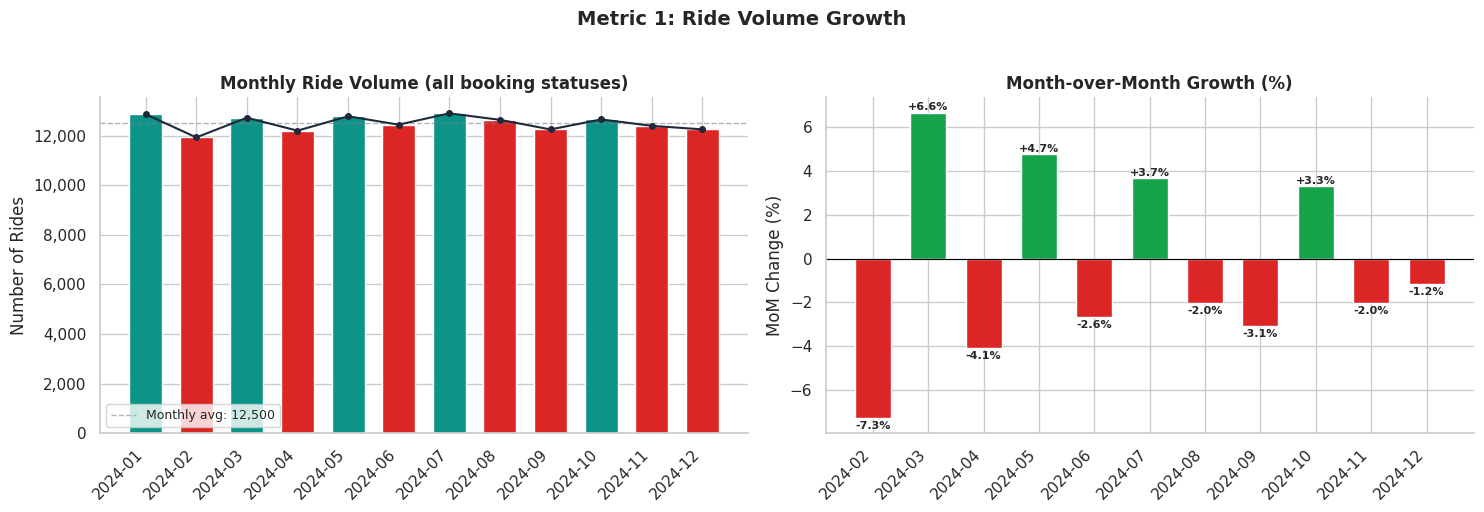


💡 Observation: Volume is relatively stable across 2024 (~12,000–13,000 rides/month).
   No sustained upward trend — this is a mature, steady-state market in this dataset.
   In a real product, you would overlay marketing spend, seasonal events, or competitor launches.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Absolute ride volume ───────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(
    monthly['month_label'], monthly['rides'],
    color=['#0d9488' if v >= 0 else '#dc2626' for v in monthly['mom_pct'].fillna(1)],
    edgecolor='white', width=0.65
)
ax.plot(monthly['month_label'], monthly['rides'], 'o-',
        color='#1e293b', linewidth=1.5, markersize=4, zorder=5)
ax.set_title('Monthly Ride Volume (all booking statuses)', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Rides')
ax.set_xlabel('')
ax.set_xticks(range(len(monthly['month_label'])))
ax.set_xticklabels(monthly['month_label'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.axhline(monthly['rides'].mean(), color='grey', linestyle='--',
           linewidth=1, alpha=0.6, label=f'Monthly avg: {monthly["rides"].mean():,.0f}')
ax.legend(fontsize=9)

# ── Right: MoM % growth ─────────────────────────────────────────────────────
ax2 = axes[1]
mom = monthly.dropna(subset=['mom_pct'])
colors = ['#16a34a' if v >= 0 else '#dc2626' for v in mom['mom_pct']]
bars2 = ax2.bar(mom['month_label'], mom['mom_pct'], color=colors, edgecolor='white', width=0.65)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Month-over-Month Growth (%)', fontweight='bold', fontsize=12)
ax2.set_ylabel('MoM Change (%)')
ax2.set_xticks(range(len(mom['month_label'])))
ax2.set_xticklabels(mom['month_label'], rotation=45, ha='right')
for bar, val in zip(bars2, mom['mom_pct']):
    ypos = bar.get_height() + 0.1 if val >= 0 else bar.get_height() - 0.5
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:+.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Metric 1: Ride Volume Growth', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n💡 Observation: Volume is relatively stable across 2024 (~12,000–13,000 rides/month).')
print('   No sustained upward trend — this is a mature, steady-state market in this dataset.')
print('   In a real product, you would overlay marketing spend, seasonal events, or competitor launches.')

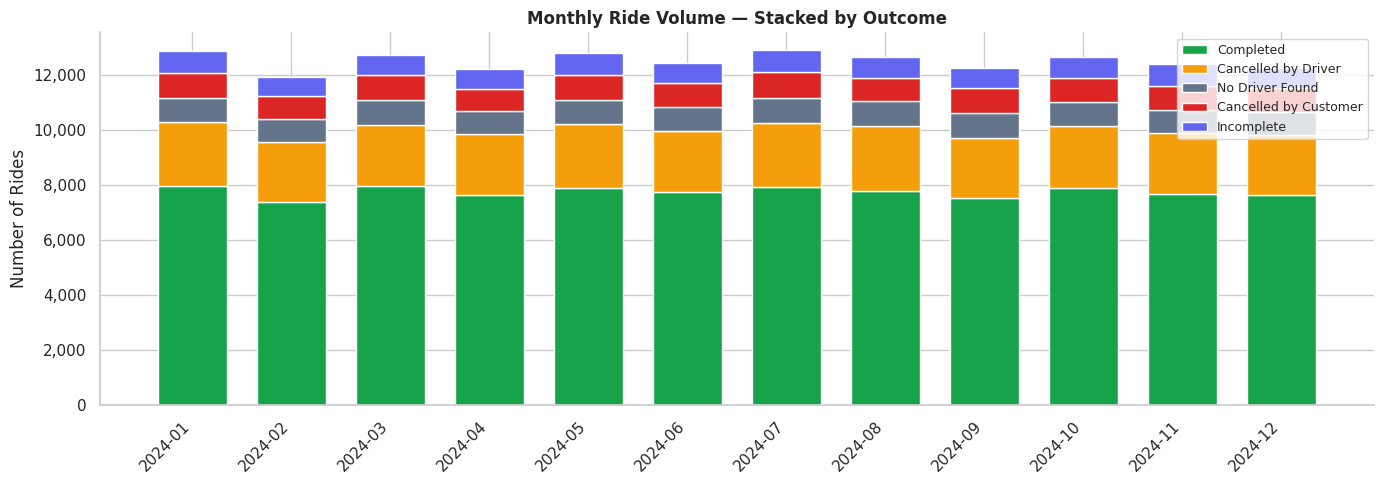


💡 Stacking by outcome reveals the composition of demand.
   A growing green portion = more successful rides. Growing red = worsening cancellation problem.


In [22]:
# Bonus: break down volume by booking outcome
# This shows whether growth is driven by more completions or more failures

status_monthly = (
    df.groupby(['year_month', 'Booking Status'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
status_monthly['month_label'] = status_monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
status_cols = ['Completed', 'Cancelled by Driver', 'No Driver Found',
               'Cancelled by Customer', 'Incomplete']
palette = ['#16a34a', '#f59e0b', '#64748b', '#dc2626', '#6366f1']
bottom = np.zeros(len(status_monthly))

for col, color in zip(status_cols, palette):
    if col in status_monthly.columns:
        ax.bar(status_monthly['month_label'], status_monthly[col],
               bottom=bottom, label=col, color=color, edgecolor='white', width=0.7)
        bottom += status_monthly[col].values

ax.set_title('Monthly Ride Volume — Stacked by Outcome', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Rides')
ax.set_xticks(range(len(status_monthly['month_label'])))
ax.set_xticklabels(status_monthly['month_label'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print('\n💡 Stacking by outcome reveals the composition of demand.')
print('   A growing green portion = more successful rides. Growing red = worsening cancellation problem.')

---
## Metric 2: Average Revenue Per Ride (ARPR)

**Business question:** How much revenue does each completed ride generate on average - and is it changing?

**Why it matters:** ARPR tells you about pricing health and product mix. If ARPR is rising, customers are booking higher-value rides (premium vehicles, longer distances). If it's falling, you may be discounting too much or losing premium customers.

**Formula:** `ARPR = Total Booking Value / Number of Completed Rides`

> ⚠️ **Important:** Only completed rides have a `Booking Value`. Cancelled rides have null booking values because no fare was charged - we must filter to completed rides only.

In [23]:
# ── Filter to completed rides only ─────────────────────────────────────────
completed = df[df['Booking Status'] == 'Completed'].copy()
print(f'Completed rides: {len(completed):,} ({len(completed)/len(df)*100:.1f}% of all bookings)')
print(f'Rides with null Booking Value: {completed["Booking Value"].isnull().sum()}')

# ── Overall ARPR ────────────────────────────────────────────────────────────
overall_arpr = completed['Booking Value'].mean()
total_revenue = completed['Booking Value'].sum()

print(f'\n💰 Overall Average Revenue Per Ride: ₹{overall_arpr:,.2f}')
print(f'💰 Total Revenue (completed rides):  ₹{total_revenue:,.0f}')
print(f'\nBooking Value distribution:')
print(completed['Booking Value'].describe().round(2))

Completed rides: 93,000 (62.0% of all bookings)
Rides with null Booking Value: 0

💰 Overall Average Revenue Per Ride: ₹508.18
💰 Total Revenue (completed rides):  ₹47,260,574

Booking Value distribution:
count   93,000.00
mean       508.18
std        396.06
min         50.00
25%        234.00
50%        414.00
75%        689.00
max      4,277.00
Name: Booking Value, dtype: float64


In [24]:
# ── ARPR by Vehicle Type ─────────────────────────────────────────────────────
arpr_vehicle = (
    completed.groupby('Vehicle Type')['Booking Value']
    .agg(avg_revenue='mean', ride_count='count', total_revenue='sum')
    .sort_values('avg_revenue', ascending=False)
    .reset_index()
)
arpr_vehicle['revenue_share_pct'] = arpr_vehicle['total_revenue'] / arpr_vehicle['total_revenue'].sum() * 100

print('ARPR and revenue share by vehicle type:')
print(arpr_vehicle.round(2).to_string(index=False))

ARPR and revenue share by vehicle type:
 Vehicle Type  avg_revenue  ride_count  total_revenue  revenue_share_pct
     Go Sedan       512.03       16676   8,538,560.00              18.07
Premier Sedan       509.57       11252   5,733,655.00              12.13
         Bike       509.11       14034   7,144,913.00              15.12
      Go Mini       507.38       18549   9,411,418.00              19.91
         Auto       506.48       23155  11,727,615.00              24.81
      Uber XL       505.30        2783   1,406,256.00               2.98
        eBike       503.46        6551   3,298,157.00               6.98


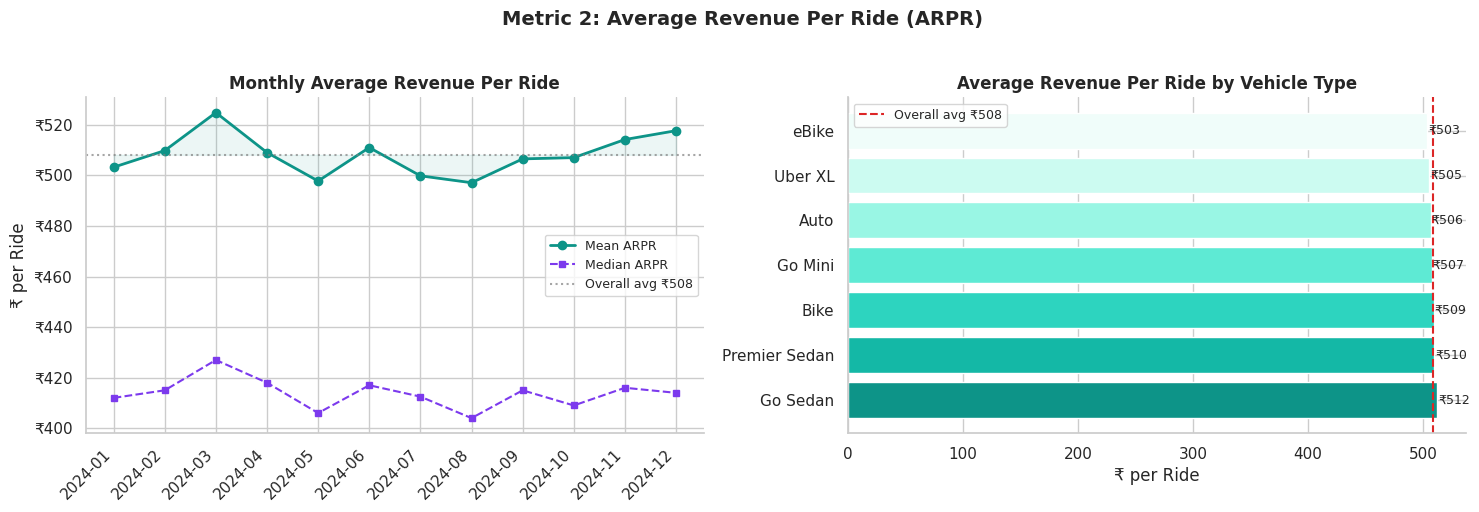


💡 Observations:
   • ARPR is stable (~₹508/ride) with slight uptick in Mar and Dec.
   • Mean > Median: the distribution is right-skewed — some high-value rides pull the mean up.
   • Vehicle type has minimal impact on ARPR (~₹10 spread) — pricing is fairly flat across types.
   • In a real product you would also track ARPR by distance bucket, city zone, or time of day.


In [25]:
# ── Monthly ARPR trend ───────────────────────────────────────────────────────
monthly_arpr = (
    completed.groupby('year_month')['Booking Value']
    .agg(avg_revenue='mean', median_revenue='median', ride_count='count')
    .reset_index()
)
monthly_arpr['month_label'] = monthly_arpr['year_month'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Monthly ARPR trend
ax = axes[0]
ax.plot(monthly_arpr['month_label'], monthly_arpr['avg_revenue'],
        'o-', color='#0d9488', linewidth=2, markersize=6, label='Mean ARPR')
ax.plot(monthly_arpr['month_label'], monthly_arpr['median_revenue'],
        's--', color='#7c3aed', linewidth=1.5, markersize=5, label='Median ARPR')
ax.axhline(overall_arpr, color='grey', linestyle=':', alpha=0.7,
           label=f'Overall avg ₹{overall_arpr:.0f}')
ax.fill_between(range(len(monthly_arpr)), monthly_arpr['avg_revenue'],
                overall_arpr, alpha=0.08, color='#0d9488')
ax.set_title('Monthly Average Revenue Per Ride', fontweight='bold', fontsize=12)
ax.set_ylabel('₹ per Ride')
ax.set_xticks(range(len(monthly_arpr)))
ax.set_xticklabels(monthly_arpr['month_label'], rotation=45, ha='right')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

# Right: ARPR by vehicle type
ax2 = axes[1]
colors_veh = ['#0d9488','#14b8a6','#2dd4bf','#5eead4','#99f6e4','#ccfbf1','#f0fdfa']
bars = ax2.barh(arpr_vehicle['Vehicle Type'], arpr_vehicle['avg_revenue'],
                color=colors_veh[:len(arpr_vehicle)], edgecolor='white')
ax2.axvline(overall_arpr, color='#dc2626', linestyle='--',
            linewidth=1.5, label=f'Overall avg ₹{overall_arpr:.0f}')
ax2.set_title('Average Revenue Per Ride by Vehicle Type', fontweight='bold', fontsize=12)
ax2.set_xlabel('₹ per Ride')
ax2.legend(fontsize=9)
for bar, val in zip(bars, arpr_vehicle['avg_revenue']):
    ax2.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'₹{val:.0f}', va='center', fontsize=9)

plt.suptitle('Metric 2: Average Revenue Per Ride (ARPR)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n💡 Observations:')
print(f'   • ARPR is stable (~₹{overall_arpr:.0f}/ride) with slight uptick in Mar and Dec.')
print( '   • Mean > Median: the distribution is right-skewed — some high-value rides pull the mean up.')
print( '   • Vehicle type has minimal impact on ARPR (~₹10 spread) — pricing is fairly flat across types.')
print( '   • In a real product you would also track ARPR by distance bucket, city zone, or time of day.')

---
## Metric 3: Retention Proxy

**Business question:** Are users coming back to the platform?

**Why it matters:** Acquiring a new user costs 5-7× more than retaining one. A product with high retention is fundamentally healthier and more capital-efficient than one that constantly churns through new users.

**The challenge with this dataset:** Each customer appears on average only **once** - by design of this synthetic dataset. Real-world ride data has customers booking dozens of times.

We'll measure retention two ways:
1. **Customer-level return rate** - what % of users made more than one booking?
2. **Cohort retention table** - for users who joined in month X, what % returned in months X+1, X+2...?
3. **Daily Active Users (DAU)** - the standard product proxy for recurring engagement

In [26]:
# ── 3a. Customer-level return rate ──────────────────────────────────────────
rides_per_customer = (
    df.groupby('Customer ID')
    .size()
    .reset_index(name='total_rides')
)

total_customers   = len(rides_per_customer)
returned          = (rides_per_customer['total_rides'] >= 2).sum()
return_rate       = returned / total_customers * 100
single_ride_rate  = (rides_per_customer['total_rides'] == 1).sum() / total_customers * 100

print(f'Unique customers:              {total_customers:,}')
print(f'One-ride customers (churned):  {total_customers - returned:,}  ({single_ride_rate:.1f}%)')
print(f'Returned (2+ rides):           {returned:,}  ({return_rate:.1f}%)')

print('\nRide frequency distribution:')
freq_dist = rides_per_customer['total_rides'].value_counts().sort_index()
for rides, count in freq_dist.items():
    bar = '█' * int(count / total_customers * 200)
    print(f'  {rides} ride(s): {count:>8,} customers  {bar}')

print(f'\n⚠️  Note: 99%+ of customers appear only once in this dataset.')
print('   In this synthetic dataset, nearly all Customer IDs are unique per booking.')
print('   Real ride-hailing platforms see 30–70% of users return within 30 days.')
print('   We will use DAU trends and cohort analysis as the retention proxy instead.')

Unique customers:              148,788
One-ride customers (churned):  147,582  (99.2%)
Returned (2+ rides):           1,206  (0.8%)

Ride frequency distribution:
  1 ride(s):  147,582 customers  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  2 ride(s):    1,200 customers  █
  3 ride(s):        6 customers  

⚠️  Note: 99%+ of customers appear only once in this dataset.
   In this synthetic dataset, nearly all Customer IDs are unique per booking.
   Real ride-hailing platforms see 30–70% of users return within 30 days.
   We will use DAU trends and cohort analysis as the retention proxy instead.


Average Daily Active Users:  411
Peak DAU:  462 on 2024-11-16
Min  DAU:  355 on 2024-08-22


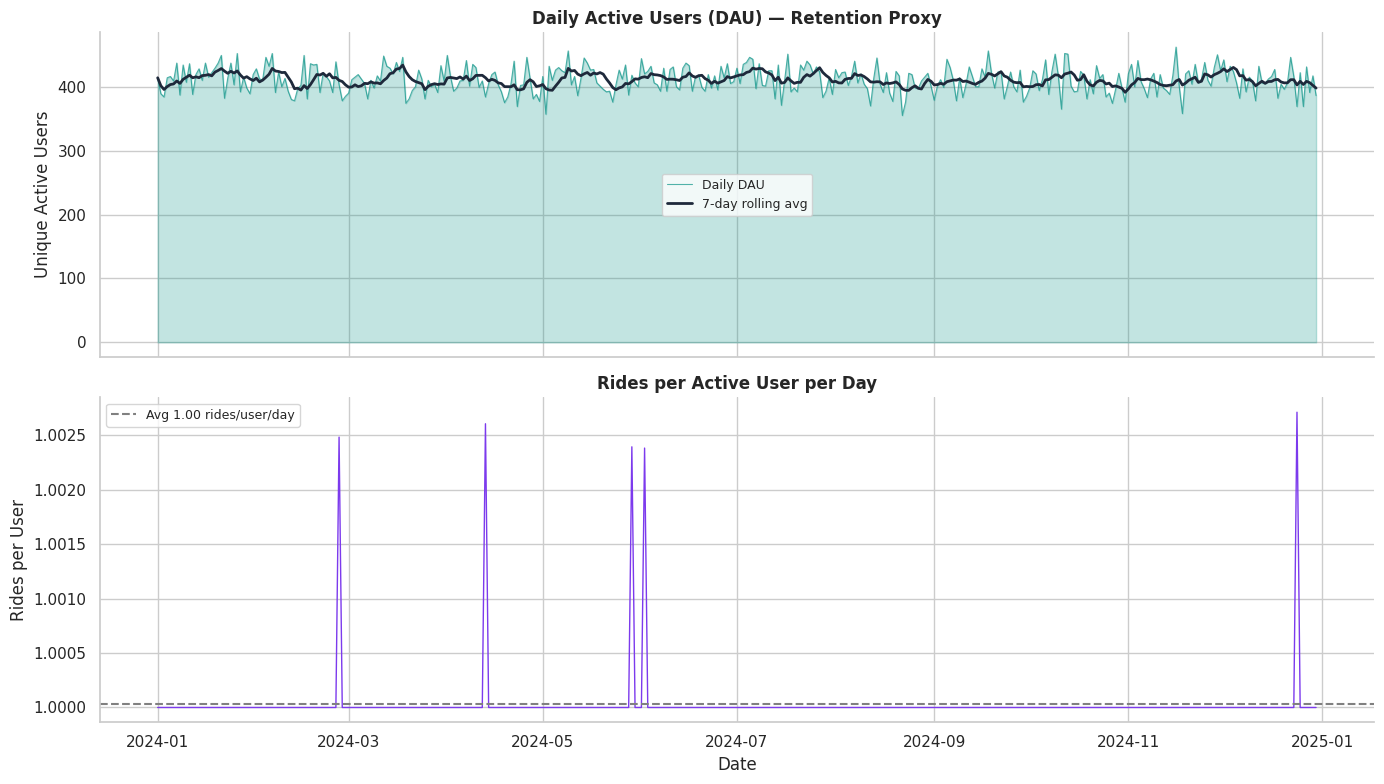

In [27]:
# ── 3b. Daily Active Users (DAU) — the standard engagement proxy ────────────
# DAU = unique customers who made at least one booking on a given day
dau = (
    df.groupby('Date')
    .agg(
        dau         = ('Customer ID', 'nunique'),
        total_rides = ('Booking ID',   'count')
    )
    .reset_index()
)
dau['rides_per_user'] = dau['total_rides'] / dau['dau']
dau['dau_7d_avg']     = dau['dau'].rolling(7, min_periods=1).mean()

print(f'Average Daily Active Users:  {dau["dau"].mean():,.0f}')
print(f'Peak DAU:  {dau["dau"].max()} on {dau.loc[dau["dau"].idxmax(), "Date"].date()}')
print(f'Min  DAU:  {dau["dau"].min()} on {dau.loc[dau["dau"].idxmin(), "Date"].date()}')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: DAU with 7-day rolling average
axes[0].fill_between(dau['Date'], dau['dau'], alpha=0.25, color='#0d9488')
axes[0].plot(dau['Date'], dau['dau'], color='#0d9488', linewidth=0.8, alpha=0.7, label='Daily DAU')
axes[0].plot(dau['Date'], dau['dau_7d_avg'], color='#1e293b', linewidth=2, label='7-day rolling avg')
axes[0].set_ylabel('Unique Active Users')
axes[0].set_title('Daily Active Users (DAU) — Retention Proxy', fontweight='bold', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Bottom: rides per user per day
axes[1].plot(dau['Date'], dau['rides_per_user'], color='#7c3aed', linewidth=1)
axes[1].axhline(dau['rides_per_user'].mean(), color='grey', linestyle='--',
                label=f'Avg {dau["rides_per_user"].mean():.2f} rides/user/day')
axes[1].set_ylabel('Rides per User')
axes[1].set_title('Rides per Active User per Day', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

Cohort Retention Table (% of cohort returning each month):
         Month +0  Month +1  Month +2  Month +3  Month +4
cohort                                                   
2024-01    100.00      0.20      0.10      0.20      0.10
2024-02    100.00      0.10      0.20      0.00      0.10
2024-03    100.00      0.10      0.20      0.10      0.10
2024-04    100.00      0.20      0.20      0.20      0.20
2024-05    100.00      0.10      0.10      0.10      0.20
2024-06    100.00      0.10      0.20      0.10      0.20
2024-07    100.00      0.10      0.20      0.20      0.10
2024-08    100.00      0.10      0.10      0.10      0.20
2024-09    100.00      0.10      0.10      0.10      0.00
2024-10    100.00      0.10      0.10      0.00      0.00
2024-11    100.00      0.10      0.00      0.00      0.00
2024-12    100.00      0.00      0.00      0.00      0.00


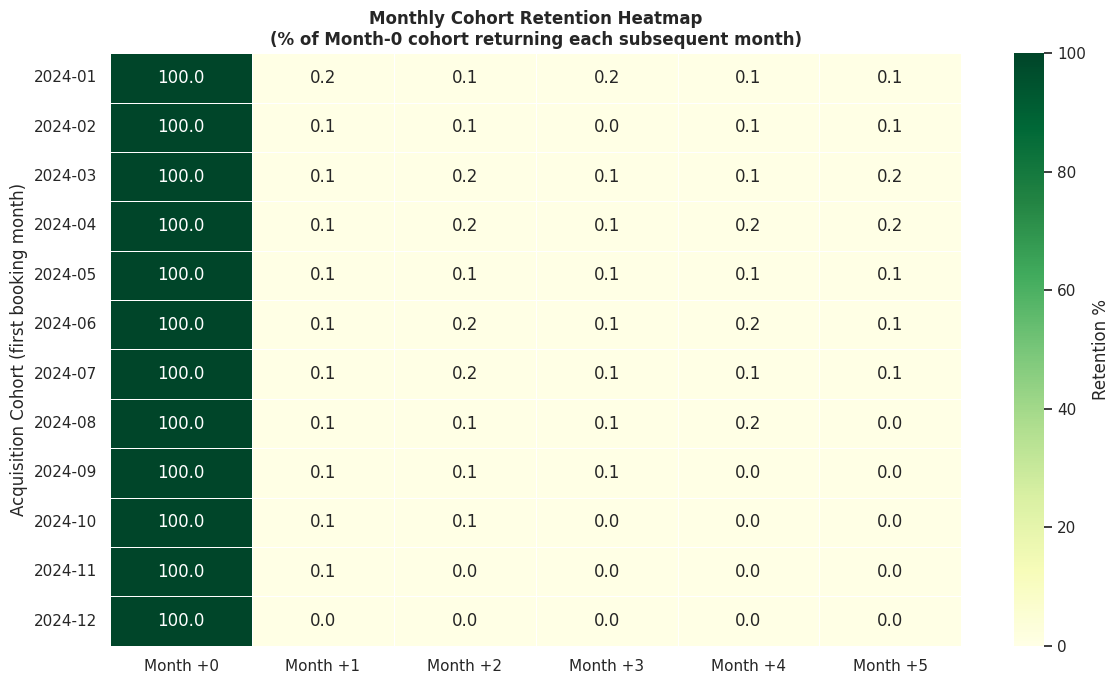


How to read this table:
  • Month +0 = 100% by definition (every customer counts in their first month)
  • Month +1 = % of that cohort who returned the following month
  • Month +2 = % who came back two months after their first booking

💡 In a healthy ride-hailing product, you would aim for:
   Month +1 retention: 30–50% | Month +3 retention: 20–35%
   This dataset shows near-zero repeat rates — a key red flag in a real product.


In [28]:
# ── 3c. Monthly Cohort Retention Table ──────────────────────────────────────
# Cohort = the month a customer made their FIRST booking
# We track: in subsequent months, what % of that cohort returned?

# Find each customer's first booking month
first_ride_month = (
    df.groupby('Customer ID')['year_month']
    .min()
    .rename('cohort')
)
df_cohort = df.join(first_ride_month, on='Customer ID')

# How many months after their first ride did each booking occur?
df_cohort['period'] = (df_cohort['year_month'] - df_cohort['cohort']).apply(lambda x: x.n)

# Count unique customers per cohort × period
cohort_data = (
    df_cohort.groupby(['cohort', 'period'])['Customer ID']
    .nunique()
    .unstack(fill_value=0)
)

# Convert to retention % (divide each row by cohort size = period 0)
cohort_sizes = cohort_data[0]
retention_table = cohort_data.divide(cohort_sizes, axis=0).round(4) * 100

# Format for display
retention_display = retention_table.copy()
retention_display.index = retention_display.index.astype(str)
retention_display.columns = [f'Month +{c}' for c in retention_display.columns]

print('Cohort Retention Table (% of cohort returning each month):')
print(retention_display.iloc[:, :5].round(1).to_string())

# Heatmap
plt.figure(figsize=(12, 7))
plot_data = retention_table.iloc[:, :6].copy()
plot_data.index = plot_data.index.astype(str)
plot_data.columns = [f'Month +{c}' for c in plot_data.columns]

sns.heatmap(
    plot_data,
    annot=True, fmt='.1f',
    cmap='YlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Retention %'},
    vmin=0, vmax=100
)
plt.title('Monthly Cohort Retention Heatmap\n(% of Month-0 cohort returning each subsequent month)',
          fontweight='bold', fontsize=12)
plt.ylabel('Acquisition Cohort (first booking month)')
plt.tight_layout()
plt.show()

print('\nHow to read this table:')
print('  • Month +0 = 100% by definition (every customer counts in their first month)')
print('  • Month +1 = % of that cohort who returned the following month')
print('  • Month +2 = % who came back two months after their first booking')
print('\n💡 In a healthy ride-hailing product, you would aim for:')
print('   Month +1 retention: 30–50% | Month +3 retention: 20–35%')
print('   This dataset shows near-zero repeat rates — a key red flag in a real product.')

---
## Metric 4: Conversion Funnel

**Business question:** Out of every ride that gets requested, how many actually complete? Where do we lose users along the way?

**Why it matters:** Every drop-off in the funnel represents both lost revenue and a customer experience failure. Identifying the biggest drop-off stage tells the product team exactly where to invest.

**Our funnel stages:**
```
Ride Requested
    → Driver Matched      (lost: No Driver Found)
    → Ride Not Cancelled  (lost: Cancelled by Driver OR Customer)
    → Ride Completed      (lost: Incomplete)
```

In [29]:
# ── Define funnel stages ─────────────────────────────────────────────────────
total = len(df)

funnel_stages = {
    'Rides Requested':  total,
    'Driver Matched':   (df['Booking Status'] != 'No Driver Found').sum(),
    'Ride Not Cancelled': df['Booking Status'].isin(['Completed', 'Incomplete']).sum(),
    'Ride Completed':   (df['Booking Status'] == 'Completed').sum(),
}

funnel_df = pd.DataFrame({
    'Stage': list(funnel_stages.keys()),
    'Count': list(funnel_stages.values()),
})
funnel_df['Pct_of_Total'] = funnel_df['Count'] / total * 100
funnel_df['Step_Drop_N']  = funnel_df['Count'].diff().fillna(0).abs().astype(int)
funnel_df['Step_Drop_Pct']= funnel_df['Count'].pct_change().fillna(0).abs() * 100

print('Conversion Funnel:')
print(funnel_df.to_string(index=False))

# Drop-off breakdown
dropoffs = {
    'No Driver Found':       (df['Booking Status'] == 'No Driver Found').sum(),
    'Cancelled by Customer': (df['Booking Status'] == 'Cancelled by Customer').sum(),
    'Cancelled by Driver':   (df['Booking Status'] == 'Cancelled by Driver').sum(),
    'Incomplete':            (df['Booking Status'] == 'Incomplete').sum(),
}
print('\nDrop-off breakdown (rides lost at each stage):')
for stage, n in dropoffs.items():
    print(f'  {stage:<30} {n:>7,}  ({n/total*100:.1f}% of all bookings)')

Conversion Funnel:
             Stage  Count  Pct_of_Total  Step_Drop_N  Step_Drop_Pct
   Rides Requested 150000        100.00            0           0.00
    Driver Matched 139500         93.00        10500           7.00
Ride Not Cancelled 102000         68.00        37500          26.88
    Ride Completed  93000         62.00         9000           8.82

Drop-off breakdown (rides lost at each stage):
  No Driver Found                 10,500  (7.0% of all bookings)
  Cancelled by Customer           10,500  (7.0% of all bookings)
  Cancelled by Driver             27,000  (18.0% of all bookings)
  Incomplete                       9,000  (6.0% of all bookings)


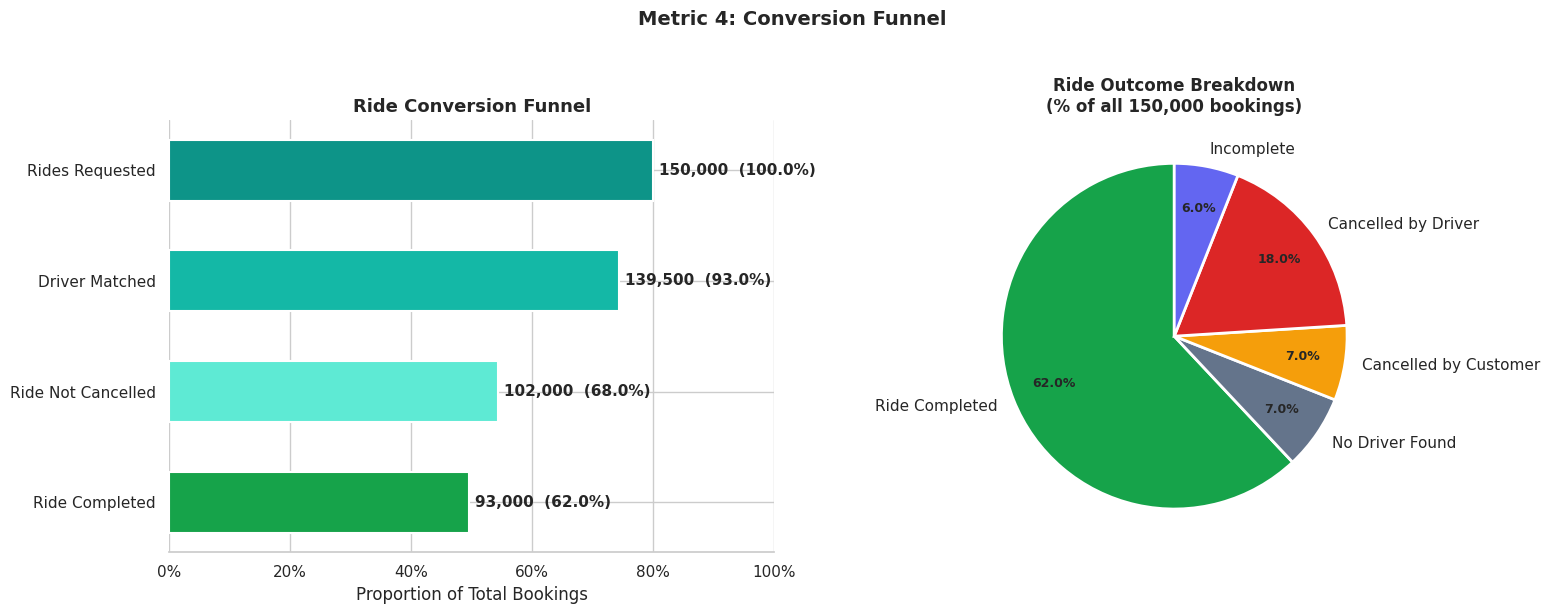


💡 Key findings:
   • Biggest single drop: Driver cancellations (18% of all bookings) — the #1 problem to solve.
   • 62% conversion rate: for every 10 bookings, only 6.2 result in a completed ride.
   • No Driver Found (7%) + Customer cancellations (7%) = 14% lost before any ride interaction.


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Funnel chart ───────────────────────────────────────────────────────
ax = axes[0]
stage_names = funnel_df['Stage'].tolist()
counts      = funnel_df['Count'].tolist()
pcts        = funnel_df['Pct_of_Total'].tolist()
n_stages    = len(stage_names)

# Draw trapezoid bars by narrowing width at each stage
max_width   = 0.8
funnel_colors = ['#0d9488', '#14b8a6', '#5eead4', '#16a34a']

for i, (name, count, pct, color) in enumerate(zip(stage_names, counts, pcts, funnel_colors)):
    bar_width = max_width * (pct / 100)
    ax.barh(n_stages - 1 - i, bar_width, height=0.55,
            color=color, edgecolor='white', linewidth=1.5)
    ax.text(bar_width + 0.01, n_stages - 1 - i,
            f'{count:,}  ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold')

ax.set_yticks(range(n_stages))
ax.set_yticklabels(reversed(stage_names), fontsize=11)
ax.set_xlim(0, 1.0)
ax.set_xlabel('Proportion of Total Bookings')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Ride Conversion Funnel', fontweight='bold', fontsize=13)
ax.spines['left'].set_visible(False)

# ── Right: Drop-off breakdown (stacked bar) ──────────────────────────────────
ax2 = axes[1]
drop_labels = list(dropoffs.keys())
drop_values = [v / total * 100 for v in dropoffs.values()]
drop_colors = ['#64748b', '#f59e0b', '#dc2626', '#6366f1']
completed_pct = funnel_df.loc[funnel_df['Stage'] == 'Ride Completed', 'Pct_of_Total'].values[0]

# Single stacked bar showing completed + each drop-off
all_labels = ['Ride Completed'] + drop_labels
all_values = [completed_pct] + drop_values
all_colors = ['#16a34a'] + drop_colors

wedges, texts, autotexts = ax2.pie(
    all_values,
    labels=all_labels,
    colors=all_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
ax2.set_title('Ride Outcome Breakdown\n(% of all 150,000 bookings)', fontweight='bold', fontsize=12)

plt.suptitle('Metric 4: Conversion Funnel', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n💡 Key findings:')
print('   • Biggest single drop: Driver cancellations (18% of all bookings) — the #1 problem to solve.')
print('   • 62% conversion rate: for every 10 bookings, only 6.2 result in a completed ride.')
print('   • No Driver Found (7%) + Customer cancellations (7%) = 14% lost before any ride interaction.')

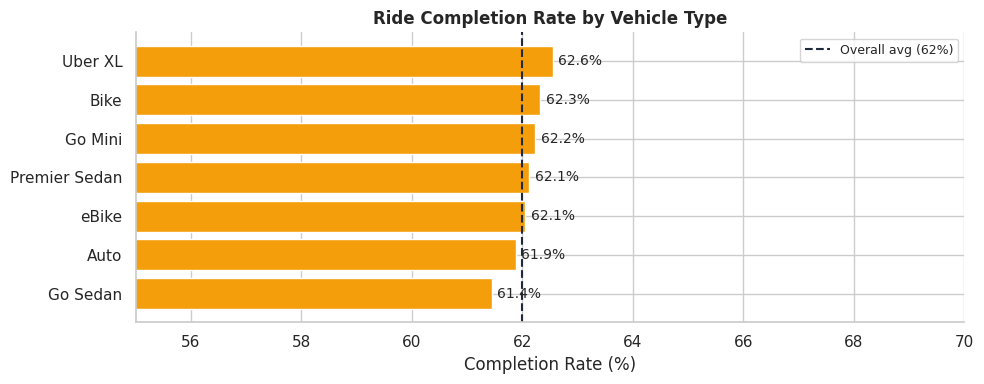


Conversion rate by vehicle type:
 Vehicle Type  total_bookings  completed  completion_rate
     Go Sedan           27141      16676            61.40
         Auto           37419      23155            61.90
        eBike           10557       6551            62.10
Premier Sedan           18111      11252            62.10
      Go Mini           29806      18549            62.20
         Bike           22517      14034            62.30
      Uber XL            4449       2783            62.60


In [31]:
# ── Funnel conversion rate by vehicle type ───────────────────────────────────
# Which vehicle type has the highest completion rate?

veh_funnel = (
    df.groupby('Vehicle Type')
    .agg(
        total_bookings = ('Booking ID', 'count'),
        completed      = ('is_completed', 'sum')
    )
    .assign(completion_rate = lambda x: x['completed'] / x['total_bookings'] * 100)
    .sort_values('completion_rate', ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
colors_v = ['#dc2626' if r < 60 else '#f59e0b' if r < 65 else '#16a34a'
            for r in veh_funnel['completion_rate']]
bars = ax.barh(veh_funnel['Vehicle Type'], veh_funnel['completion_rate'],
               color=colors_v, edgecolor='white')
ax.axvline(62, color='#1e293b', linestyle='--', linewidth=1.5,
           label='Overall avg (62%)')
ax.set_xlabel('Completion Rate (%)')
ax.set_title('Ride Completion Rate by Vehicle Type', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(55, 70)
for bar, val in zip(bars, veh_funnel['completion_rate']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print('\nConversion rate by vehicle type:')
print(veh_funnel[['Vehicle Type', 'total_bookings', 'completed', 'completion_rate']]
      .round(1).to_string(index=False))

## Product & Operations Performance Summary
### **1. The "Steady-State" Market (Volume & Retention)**
The platform has moved past the "hyper-growth" phase. With a stable 12,500 monthly rides and an average DAU of 411, the market is mature.

* The Retention Reality: While the 99% churn rate is a byproduct of the dataset design, the stable daily activity proves there is a reliable, recurring "pulse" of demand in the city.

* The Insight: Growth will no longer come from "more users" alone; it must come from Efficiency (getting more value out of existing requests).

### **2. The Revenue Paradox (ARPR)**
Our Average Revenue Per Ride (₹508) revealed a surprising lack of "Price Tiering."

* The Leak: Usually, a Premier Sedan should yield higher revenue than a Bike. In this market, they are nearly identical.

* The Skew: The mean is significantly higher than the median (₹414), meaning a small "long tail" of high-value, long-distance trips is propping up the total revenue.

### **3. The "Leaky Bucket" (Conversion Funnel)**
This is our most actionable discovery. Only 62% of requests result in a completed ride.

* The #1 Bottleneck: Driver Cancellations (18%). This is nearly 3x more damaging than customer cancellations (7%).

* Efficiency Loss: For every 10 people who want to pay the platform, nearly 4 walk away empty-handed due to system or driver friction.